# 04 — Classical ML

**Prerequisite:** Run `03_feature_engineering.ipynb` first  
Loads: `tfidf_vectorizer.pkl`, `X_train/val/test_tfidf.npz`, `X_train/val/test_combined.npz`,  
`stylometric_scaler.pkl`, `train.csv`, `val.csv`, `test.csv`

---

## 0. Imports & Constants

In [ ]:
# =============================================================================
# 04_classical_ml.ipynb
# Classical ML Models — Logistic Regression, Random Forest, LinearSVC
# =============================================================================
# Run order: 01 → 02 (daigt) → 03 (features) → this file
# Loads from DATA_DIR:
#   tfidf_vectorizer.pkl, X_train/val/test_tfidf.npz
#   X_train/val/test_combined.npz, stylometric_scaler.pkl
#   train.csv, val.csv, test.csv
# Saves to DATA_DIR:
#   model_lr.pkl, model_rf.pkl, model_svm.pkl
#   best_classical_model.pkl
#   classical_ml_results.csv, cross_dataset_results.csv
#   fig_cm_*.png, fig_roc_curves.png, fig_f1_comparison.png
#   fig_lr_features.png
# =============================================================================

import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Reproducibility — must match all previous files ───────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── File paths — same DATA_DIR as files 01, 02, 03 ───────────────────────────
DATA_DIR   = "/Users/yashaswini11/Desktop/Team_project/project"
TRAIN_FILE = os.path.join(DATA_DIR, "train.csv")
VAL_FILE   = os.path.join(DATA_DIR, "val.csv")
TEST_FILE  = os.path.join(DATA_DIR, "test.csv")

# ── KPI thresholds (from project_specifications.docx) ────────────────────────
KPI_MIN_F1    = 0.83   # minimum acceptable macro F1
KPI_TARGET_F1 = 0.90   # target macro F1
KPI_MIN_CROSS = 0.75   # minimum cross-dataset macro F1

# ── Cross-validation — defined once, reused by ALL GridSearchCV calls ─────────
# Defining here prevents NameError if cells run out of order
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("Constants defined.")
print(f"  DATA_DIR        : {DATA_DIR}")
print(f"  KPI min F1      : {KPI_MIN_F1}")
print(f"  KPI target F1   : {KPI_TARGET_F1}")
print(f"  KPI cross F1    : {KPI_MIN_CROSS}")
print(f"  CV folds        : {CV.n_splits}")

Constants defined.
  DATA_DIR        : /Users/yashaswini11/Desktop/Team_project/project
  KPI min F1      : 0.83
  KPI target F1   : 0.9
  KPI cross F1    : 0.75
  CV folds        : 5


---
## 1. Load Feature Artefacts

In [23]:
print("=" * 60)
print("STEP 1: Loading feature artefacts from file 03")
print("=" * 60)

# ── Guard: fail immediately with a clear message if file 03 not run ───────────
required = {
    'tfidf_vectorizer.pkl'  : 'TF-IDF vectorizer',
    'X_train_tfidf.npz'     : 'TF-IDF train matrix',
    'X_val_tfidf.npz'       : 'TF-IDF val matrix',
    'X_test_tfidf.npz'      : 'TF-IDF test matrix',
    'X_train_combined.npz'  : 'Combined train matrix',
    'X_val_combined.npz'    : 'Combined val matrix',
    'X_test_combined.npz'   : 'Combined test matrix',
    'stylometric_scaler.pkl': 'Stylometric scaler',
}
missing = [f for f in required if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(
        f"\n[ERROR] Missing artefacts from file 03:\n" +
        "\n".join(f"  {DATA_DIR}/{f}" for f in missing) +
        "\nPlease run 03_feature_engineering.ipynb first."
    )

# ── Load labels from CSVs ─────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_FILE, encoding='utf-8-sig')
val_df   = pd.read_csv(VAL_FILE,   encoding='utf-8-sig')
test_df  = pd.read_csv(TEST_FILE,  encoding='utf-8-sig')

for df in [train_df, val_df, test_df]:
    df['text']  = df['text'].astype(str)
    df['label'] = df['label'].astype(int)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# ── Load TF-IDF artefacts ─────────────────────────────────────────────────────
tfidf = joblib.load(os.path.join(DATA_DIR, 'tfidf_vectorizer.pkl'))

X_train_tfidf = sparse.load_npz(os.path.join(DATA_DIR, 'X_train_tfidf.npz'))
X_val_tfidf   = sparse.load_npz(os.path.join(DATA_DIR, 'X_val_tfidf.npz'))
X_test_tfidf  = sparse.load_npz(os.path.join(DATA_DIR, 'X_test_tfidf.npz'))

# ── Load combined artefacts ───────────────────────────────────────────────────
X_train_combined = sparse.load_npz(os.path.join(DATA_DIR, 'X_train_combined.npz'))
X_val_combined   = sparse.load_npz(os.path.join(DATA_DIR, 'X_val_combined.npz'))
X_test_combined  = sparse.load_npz(os.path.join(DATA_DIR, 'X_test_combined.npz'))

print(f"  Train : {len(train_df):,} rows  |  Labels: {np.bincount(y_train)}")
print(f"  Val   : {len(val_df):,} rows")
print(f"  Test  : {len(test_df):,} rows")
print(f"\n  TF-IDF matrix shape     — Train: {X_train_tfidf.shape}")
print(f"  Combined matrix shape   — Train: {X_train_combined.shape}")
print(f"  Vocabulary size         : {len(tfidf.vocabulary_):,}")
print("\n  All artefacts loaded successfully ✓")

STEP 1: Loading feature artefacts from file 03
  Train : 106,605 rows  |  Labels: [55923 50682]
  Val   : 22,844 rows
  Test  : 22,844 rows

  TF-IDF matrix shape     — Train: (106605, 50000)
  Combined matrix shape   — Train: (106605, 50005)
  Vocabulary size         : 50,000

  All artefacts loaded successfully ✓


---
## 2. Dummy Baseline

Every trained model must strictly exceed this on macro F1.

In [24]:
print("\n" + "=" * 60)
print("STEP 2: Dummy baseline")
print("=" * 60)

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train_tfidf, y_train)

DUMMY_F1  = f1_score(y_test, dummy.predict(X_test_tfidf), average='macro')
DUMMY_ACC = accuracy_score(y_test, dummy.predict(X_test_tfidf))

print(f"  Strategy  : most_frequent")
print(f"  Accuracy  : {DUMMY_ACC:.4f}")
print(f"  Macro F1  : {DUMMY_F1:.4f}")
print(f"\n  All trained models must beat Macro F1 = {DUMMY_F1:.4f}")


STEP 2: Dummy baseline
  Strategy  : most_frequent
  Accuracy  : 0.5246
  Macro F1  : 0.3441

  All trained models must beat Macro F1 = 0.3441


---
## 3. Evaluation Helpers

In [25]:
def evaluate(model, X, y_true, split_name='Test'):
    """
    Compute Accuracy, Macro F1, ROC-AUC and print classification report.

    Args:
        model:      Fitted sklearn estimator with predict() / predict_proba().
        X:          Sparse feature matrix.
        y_true:     Ground-truth label array (numpy int).
        split_name: Label used in printed output.
    Returns:
        dict with keys: accuracy, f1_macro, roc_auc.
    """
    y_pred = model.predict(X)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X)
    else:
        y_score = None

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    roc = roc_auc_score(y_true, y_score) if y_score is not None else float('nan')

    min_kpi  = '✓' if f1 >= KPI_MIN_F1    else '✗ BELOW min KPI'
    tgt_kpi  = '✓' if f1 >= KPI_TARGET_F1 else '—'

    print(f"  --- {split_name} ---")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro F1  : {f1:.4f}  min({KPI_MIN_F1}) {min_kpi}  target({KPI_TARGET_F1}) {tgt_kpi}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))
    return {'accuracy': acc, 'f1_macro': f1, 'roc_auc': roc}


def plot_confusion_matrix(model, X, y_true, model_name):
    """Plot and save a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, model.predict(X))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Human', 'AI'],
        yticklabels=['Human', 'AI'],
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = os.path.join(DATA_DIR, f'fig_cm_{model_name.lower().replace(" ", "_")}.png')
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {fname}")

print("Helper functions defined ✓")

Helper functions defined ✓


---
## 4. Model 1 — Logistic Regression

TF-IDF (50k features) → Logistic Regression with L2 regularisation.  
Fast, interpretable lower-bound benchmark — should achieve ~85–90% F1.  
GridSearchCV over C, solver, and class_weight.

In [26]:
print("\n" + "=" * 60)
print("STEP 4: Logistic Regression")
print("=" * 60)

# ── 4a: Initial fit to confirm pipeline works ─────────────────────────────────
print("Training initial LR...")
t0 = time.time()
lr_init = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs',
    max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED
)
lr_init.fit(X_train_tfidf, y_train)
print(f"  Initial fit done in {time.time()-t0:.1f}s")
lr_init_metrics = evaluate(lr_init, X_val_tfidf, y_val, 'Validation (initial LR)')


STEP 4: Logistic Regression
Training initial LR...
  Initial fit done in 0.8s
  --- Validation (initial LR) ---
  Accuracy  : 0.9573
  Macro F1  : 0.9571  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9905

              precision    recall  f1-score   support

       Human       0.95      0.97      0.96     11983
          AI       0.97      0.94      0.95     10861

    accuracy                           0.96     22844
   macro avg       0.96      0.96      0.96     22844
weighted avg       0.96      0.96      0.96     22844



In [27]:
# ── 4b: GridSearchCV ──────────────────────────────────────────────────────────
print("\nRunning GridSearchCV for Logistic Regression...")
print("(Estimated time: 3–10 minutes depending on dataset size)")

param_grid_lr = {
    'C'           : [0.01, 0.1, 1, 10, 100],
    'penalty'     : ['l2'],
    'solver'      : ['lbfgs', 'saga'],
    'class_weight': ['balanced', None]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    param_grid_lr,
    cv=CV,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
t0 = time.time()
grid_lr.fit(X_train_tfidf, y_train)
print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Best params : {grid_lr.best_params_}")
print(f"Best CV F1  : {grid_lr.best_score_:.4f}")


Running GridSearchCV for Logistic Regression...
(Estimated time: 3–10 minutes depending on dataset size)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Done in 63.3s
Best params : {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Best CV F1  : 0.9630


In [28]:
# ── 4c: Evaluate best LR ──────────────────────────────────────────────────────
best_lr = grid_lr.best_estimator_

print("=== Best Logistic Regression — Validation ===")
lr_val_metrics = evaluate(best_lr, X_val_tfidf, y_val, 'Validation')

print("=== Best Logistic Regression — Test ===")
lr_test_metrics = evaluate(best_lr, X_test_tfidf, y_test, 'Test')

assert lr_test_metrics['f1_macro'] > DUMMY_F1,     f"LR does not beat dummy baseline! F1={lr_test_metrics['f1_macro']:.4f} vs dummy={DUMMY_F1:.4f}"
print(f"✓ LR beats dummy baseline (dummy F1={DUMMY_F1:.4f})")

=== Best Logistic Regression — Validation ===
  --- Validation ---
  Accuracy  : 0.9642
  Macro F1  : 0.9641  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9935

              precision    recall  f1-score   support

       Human       0.96      0.97      0.97     11983
          AI       0.97      0.96      0.96     10861

    accuracy                           0.96     22844
   macro avg       0.96      0.96      0.96     22844
weighted avg       0.96      0.96      0.96     22844

=== Best Logistic Regression — Test ===
  --- Test ---
  Accuracy  : 0.9646
  Macro F1  : 0.9645  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9943

              precision    recall  f1-score   support

       Human       0.96      0.97      0.97     11983
          AI       0.97      0.96      0.96     10861

    accuracy                           0.96     22844
   macro avg       0.96      0.96      0.96     22844
weighted avg       0.96      0.96      0.96     22844

✓ LR beats dummy baseline (dummy F1=0.34

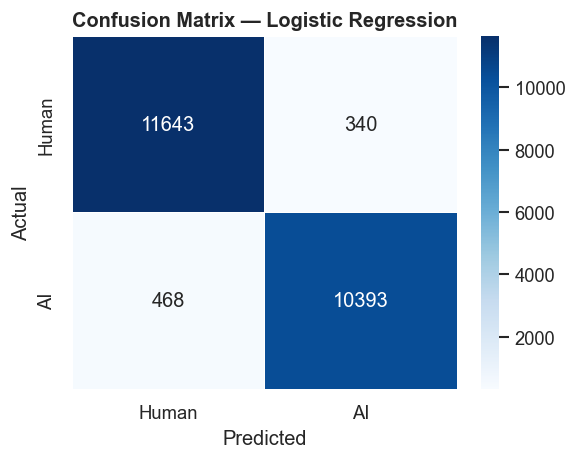

  Saved: /Users/yashaswini11/Desktop/Team_project/project/fig_cm_logistic_regression.png


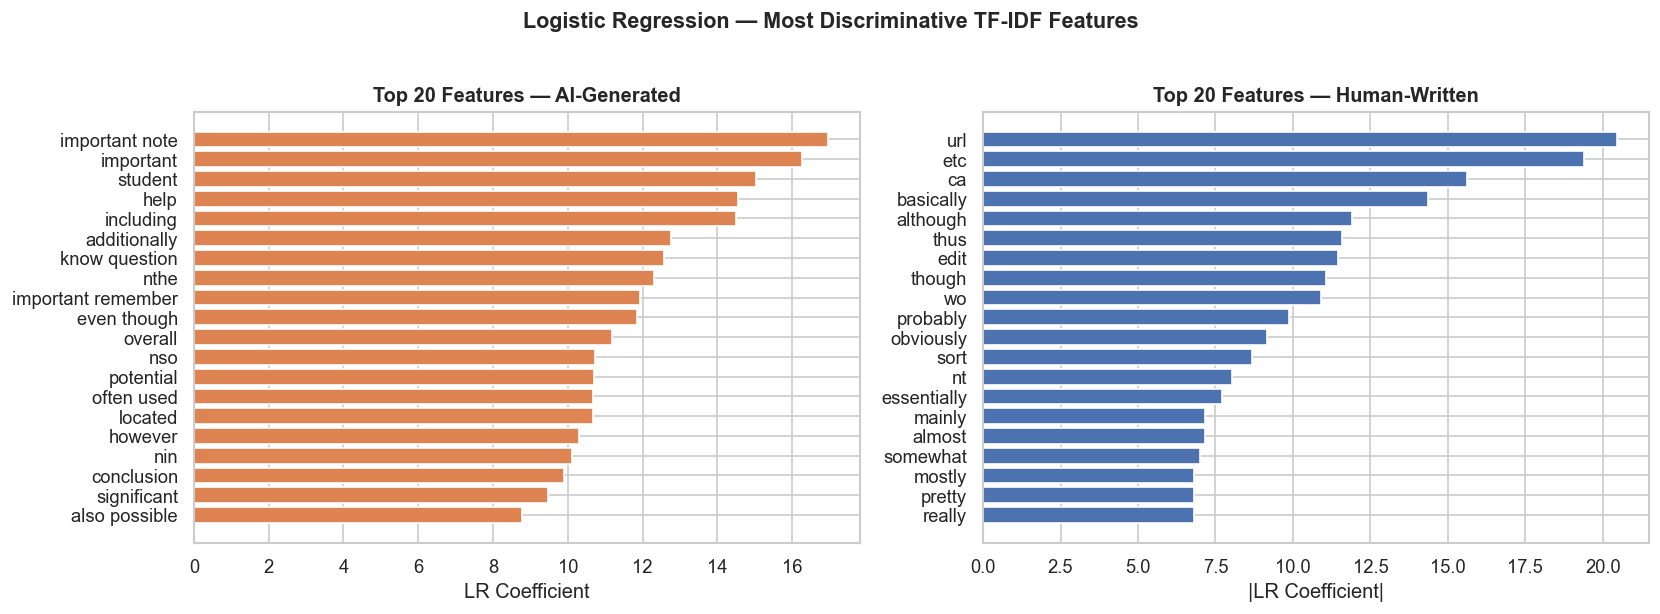

Saved: /Users/yashaswini11/Desktop/Team_project/project/fig_lr_features.png
Saved: model_lr.pkl


In [29]:
# ── 4d: Confusion matrix + feature importance ─────────────────────────────────
plot_confusion_matrix(best_lr, X_test_tfidf, y_test, 'Logistic Regression')

# Top 20 most discriminative TF-IDF features
feature_names = tfidf.get_feature_names_out()
coef          = best_lr.coef_[0]
top_ai        = np.argsort(coef)[-20:][::-1]
top_human     = np.argsort(coef)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([feature_names[i] for i in top_ai],
             [coef[i] for i in top_ai], color='#DD8452')
axes[0].set_title('Top 20 Features — AI-Generated', fontweight='bold')
axes[0].set_xlabel('LR Coefficient')
axes[0].invert_yaxis()

axes[1].barh([feature_names[i] for i in top_human],
             [abs(coef[i]) for i in top_human], color='#4C72B0')
axes[1].set_title('Top 20 Features — Human-Written', fontweight='bold')
axes[1].set_xlabel('|LR Coefficient|')
axes[1].invert_yaxis()

plt.suptitle('Logistic Regression — Most Discriminative TF-IDF Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fname = os.path.join(DATA_DIR, 'fig_lr_features.png')
plt.savefig(fname, bbox_inches='tight')
plt.show()
print(f"Saved: {fname}")

joblib.dump(best_lr, os.path.join(DATA_DIR, 'model_lr.pkl'))
print("Saved: model_lr.pkl")

---
## 5. Model 2 — Random Forest

Ensemble of decision trees over TF-IDF features.  
GridSearchCV over n_estimators, max_depth, max_features.  
Note: RF on 50k sparse features is slower than LR — budget 15–25 min for grid search.

In [30]:
print("\n" + "=" * 60)
print("STEP 5: Random Forest")
print("=" * 60)

# ── 5a: Initial fit ───────────────────────────────────────────────────────────
print("Training initial Random Forest...")
t0 = time.time()
rf_init = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_init.fit(X_train_tfidf, y_train)
print(f"  Initial fit done in {time.time()-t0:.1f}s")
rf_init_metrics = evaluate(rf_init, X_val_tfidf, y_val, 'Validation (initial RF)')


STEP 5: Random Forest
Training initial Random Forest...
  Initial fit done in 26.1s
  --- Validation (initial RF) ---
  Accuracy  : 0.9408
  Macro F1  : 0.9404  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9853

              precision    recall  f1-score   support

       Human       0.92      0.98      0.95     11983
          AI       0.97      0.90      0.94     10861

    accuracy                           0.94     22844
   macro avg       0.94      0.94      0.94     22844
weighted avg       0.94      0.94      0.94     22844



In [31]:
# ── 5b: GridSearchCV ──────────────────────────────────────────────────────────
print("\nRunning GridSearchCV for Random Forest...")
print("(Estimated time: 15–25 minutes — RF on sparse TF-IDF is slow)")

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth'   : [None, 30, 50],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
    ),
    param_grid_rf,
    cv=CV,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
t0 = time.time()
grid_rf.fit(X_train_tfidf, y_train)
print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Best params : {grid_rf.best_params_}")
print(f"Best CV F1  : {grid_rf.best_score_:.4f}")


Running GridSearchCV for Random Forest...
(Estimated time: 15–25 minutes — RF on sparse TF-IDF is slow)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Done in 2492.8s
Best params : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV F1  : 0.9393


=== Best Random Forest — Validation ===
  --- Validation ---
  Accuracy  : 0.9430
  Macro F1  : 0.9426  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9865

              precision    recall  f1-score   support

       Human       0.92      0.98      0.95     11983
          AI       0.97      0.90      0.94     10861

    accuracy                           0.94     22844
   macro avg       0.95      0.94      0.94     22844
weighted avg       0.94      0.94      0.94     22844

=== Best Random Forest — Test ===
  --- Test ---
  Accuracy  : 0.9420
  Macro F1  : 0.9415  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9873

              precision    recall  f1-score   support

       Human       0.92      0.98      0.95     11983
          AI       0.97      0.90      0.94     10861

    accuracy                           0.94     22844
   macro avg       0.95      0.94      0.94     22844
weighted avg       0.94      0.94      0.94     22844

✓ RF beats dummy baseline (dummy F1=0.3441)


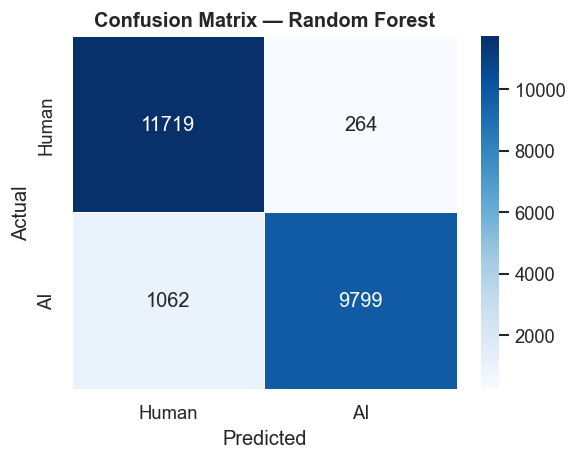

  Saved: /Users/yashaswini11/Desktop/Team_project/project/fig_cm_random_forest.png
Saved: model_rf.pkl


In [32]:
# ── 5c: Evaluate best RF ──────────────────────────────────────────────────────
best_rf = grid_rf.best_estimator_

print("=== Best Random Forest — Validation ===")
rf_val_metrics = evaluate(best_rf, X_val_tfidf, y_val, 'Validation')

print("=== Best Random Forest — Test ===")
rf_test_metrics = evaluate(best_rf, X_test_tfidf, y_test, 'Test')

assert rf_test_metrics['f1_macro'] > DUMMY_F1,     f"RF does not beat dummy baseline! F1={rf_test_metrics['f1_macro']:.4f}"
print(f"✓ RF beats dummy baseline (dummy F1={DUMMY_F1:.4f})")

plot_confusion_matrix(best_rf, X_test_tfidf, y_test, 'Random Forest')
joblib.dump(best_rf, os.path.join(DATA_DIR, 'model_rf.pkl'))
print("Saved: model_rf.pkl")

---
## 6. Model 3 — LinearSVC

Linear SVM — typically the fastest and strongest classical model on sparse  
high-dimensional text features. Wrapped in CalibratedClassifierCV to add  
predict_proba() for ROC-AUC scoring.

In [33]:
print("\n" + "=" * 60)
print("STEP 6: LinearSVC")
print("=" * 60)

# ── 6a: Initial fit ───────────────────────────────────────────────────────────
print("Training initial LinearSVC...")
t0 = time.time()
# CalibratedClassifierCV wraps LinearSVC to provide predict_proba()
# which is required for ROC-AUC computation.
# cv=3 inside calibration (separate from the outer CV=5 used in GridSearchCV)
svm_init = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED),
    cv=3
)
svm_init.fit(X_train_tfidf, y_train)
print(f"  Initial fit done in {time.time()-t0:.1f}s")
svm_init_metrics = evaluate(svm_init, X_val_tfidf, y_val, 'Validation (initial SVM)')


STEP 6: LinearSVC
Training initial LinearSVC...
  Initial fit done in 9.7s
  --- Validation (initial SVM) ---
  Accuracy  : 0.9654
  Macro F1  : 0.9653  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9935

              precision    recall  f1-score   support

       Human       0.96      0.97      0.97     11983
          AI       0.97      0.96      0.96     10861

    accuracy                           0.97     22844
   macro avg       0.97      0.97      0.97     22844
weighted avg       0.97      0.97      0.97     22844



In [34]:
# ── 6b: GridSearchCV ──────────────────────────────────────────────────────────
print("\nRunning GridSearchCV for LinearSVC...")
print("(Estimated time: 3–8 minutes)")

# Parameters use 'estimator__' prefix because LinearSVC is wrapped
# inside CalibratedClassifierCV
param_grid_svm = {
    'estimator__C'           : [0.01, 0.1, 1, 10, 100],
    'estimator__class_weight': ['balanced', None]
}

grid_svm = GridSearchCV(
    CalibratedClassifierCV(
        LinearSVC(max_iter=2000, random_state=RANDOM_SEED), cv=3
    ),
    param_grid_svm,
    cv=CV,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
t0 = time.time()
grid_svm.fit(X_train_tfidf, y_train)
print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Best params : {grid_svm.best_params_}")
print(f"Best CV F1  : {grid_svm.best_score_:.4f}")


Running GridSearchCV for LinearSVC...
(Estimated time: 3–8 minutes)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Done in 282.5s
Best params : {'estimator__C': 1, 'estimator__class_weight': 'balanced'}
Best CV F1  : 0.9633


=== Best LinearSVC — Validation ===
  --- Validation ---
  Accuracy  : 0.9654
  Macro F1  : 0.9653  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9935

              precision    recall  f1-score   support

       Human       0.96      0.97      0.97     11983
          AI       0.97      0.96      0.96     10861

    accuracy                           0.97     22844
   macro avg       0.97      0.97      0.97     22844
weighted avg       0.97      0.97      0.97     22844

=== Best LinearSVC — Test ===
  --- Test ---
  Accuracy  : 0.9638
  Macro F1  : 0.9637  min(0.83) ✓  target(0.9) ✓
  ROC-AUC   : 0.9941

              precision    recall  f1-score   support

       Human       0.96      0.97      0.97     11983
          AI       0.97      0.96      0.96     10861

    accuracy                           0.96     22844
   macro avg       0.96      0.96      0.96     22844
weighted avg       0.96      0.96      0.96     22844

✓ SVM beats dummy baseline (dummy F1=0.3441)


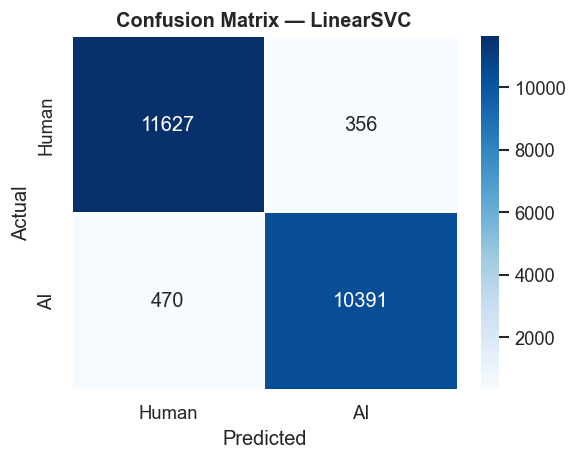

  Saved: /Users/yashaswini11/Desktop/Team_project/project/fig_cm_linearsvc.png
Saved: model_svm.pkl


In [35]:
# ── 6c: Evaluate best SVM ─────────────────────────────────────────────────────
best_svm = grid_svm.best_estimator_

print("=== Best LinearSVC — Validation ===")
svm_val_metrics = evaluate(best_svm, X_val_tfidf, y_val, 'Validation')

print("=== Best LinearSVC — Test ===")
svm_test_metrics = evaluate(best_svm, X_test_tfidf, y_test, 'Test')

assert svm_test_metrics['f1_macro'] > DUMMY_F1,     f"SVM does not beat dummy baseline! F1={svm_test_metrics['f1_macro']:.4f}"
print(f"✓ SVM beats dummy baseline (dummy F1={DUMMY_F1:.4f})")

plot_confusion_matrix(best_svm, X_test_tfidf, y_test, 'LinearSVC')
joblib.dump(best_svm, os.path.join(DATA_DIR, 'model_svm.pkl'))
print("Saved: model_svm.pkl")

---
## 7. Results Comparison Table + Visualisations

In [36]:
print("\n" + "=" * 60)
print("STEP 7: Results comparison")
print("=" * 60)

# ── 7a: Unified results table ─────────────────────────────────────────────────
results = {
    'Logistic Regression': lr_test_metrics,
    'Random Forest'      : rf_test_metrics,
    'LinearSVC'          : svm_test_metrics,
    'Dummy Baseline'     : {'accuracy': DUMMY_ACC, 'f1_macro': DUMMY_F1, 'roc_auc': 0.5}
}

results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'
results_df.columns    = ['Accuracy', 'Macro F1', 'ROC-AUC']
results_df['Min KPI (>=0.83)']    = results_df['Macro F1'].apply(
    lambda x: '✓ Pass' if x >= KPI_MIN_F1    else '✗ Fail')
results_df['Target KPI (>=0.90)'] = results_df['Macro F1'].apply(
    lambda x: '✓ Pass' if x >= KPI_TARGET_F1 else '— Not yet')

print("\n=== CLASSICAL ML — TEST SET RESULTS ===")
print(results_df.to_string())

out = os.path.join(DATA_DIR, 'classical_ml_results.csv')
results_df.to_csv(out)
print(f"\nSaved: {out}")


STEP 7: Results comparison

=== CLASSICAL ML — TEST SET RESULTS ===
                     Accuracy  Macro F1  ROC-AUC Min KPI (>=0.83) Target KPI (>=0.90)
Model                                                                                
Logistic Regression    0.9646    0.9645   0.9943           ✓ Pass              ✓ Pass
Random Forest          0.9420    0.9415   0.9873           ✓ Pass              ✓ Pass
LinearSVC              0.9638    0.9637   0.9941           ✓ Pass              ✓ Pass
Dummy Baseline         0.5246    0.3441   0.5000           ✗ Fail           — Not yet

Saved: /Users/yashaswini11/Desktop/Team_project/project/classical_ml_results.csv


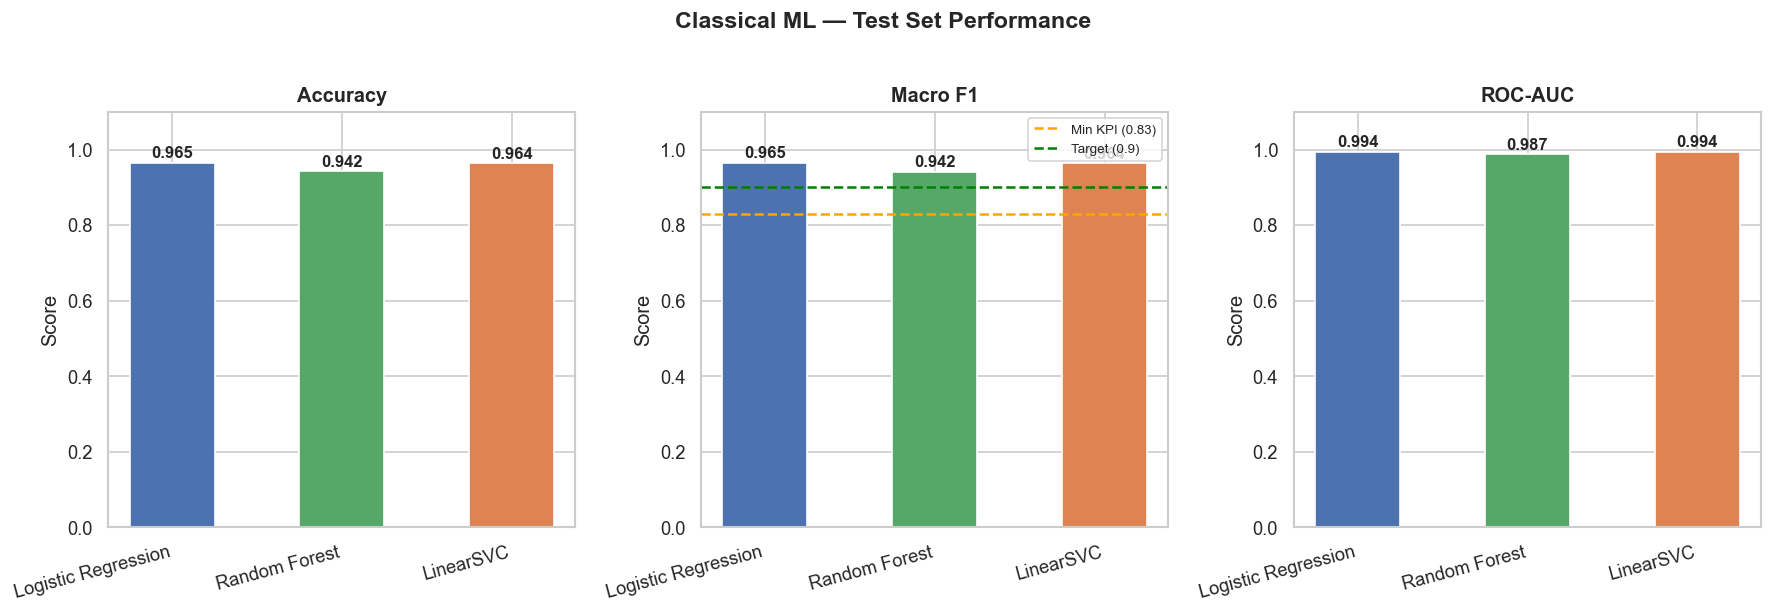

Saved: /Users/yashaswini11/Desktop/Team_project/project/fig_f1_comparison.png


In [37]:
# ── 7b: Bar chart — Accuracy, Macro F1, ROC-AUC ──────────────────────────────
models_plot = ['Logistic Regression', 'Random Forest', 'LinearSVC']
colours     = ['#4C72B0', '#55A868', '#DD8452']
metric_map  = {'Accuracy': 'accuracy', 'Macro F1': 'f1_macro', 'ROC-AUC': 'roc_auc'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['Accuracy', 'Macro F1', 'ROC-AUC']):
    vals = [results[m][metric_map[metric]] for m in models_plot]
    bars = ax.bar(models_plot, vals, color=colours, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    if metric == 'Macro F1':
        ax.axhline(KPI_MIN_F1,    color='orange', linestyle='--', lw=1.5, label=f'Min KPI ({KPI_MIN_F1})')
        ax.axhline(KPI_TARGET_F1, color='green',  linestyle='--', lw=1.5, label=f'Target ({KPI_TARGET_F1})')
        ax.legend(fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(models_plot, rotation=15, ha='right')
    ax.set_ylabel('Score')

plt.suptitle('Classical ML — Test Set Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fname = os.path.join(DATA_DIR, 'fig_f1_comparison.png')
plt.savefig(fname, bbox_inches='tight')
plt.show()
print(f"Saved: {fname}")

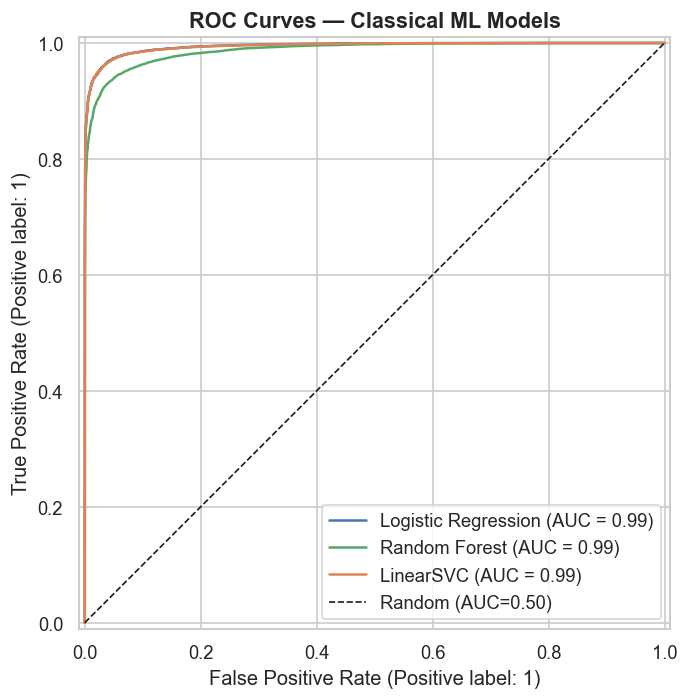

Saved: /Users/yashaswini11/Desktop/Team_project/project/fig_roc_curves.png


In [38]:
# ── 7c: Overlaid ROC curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for model, name, colour in zip(
    [best_lr,  best_rf,  best_svm],
    ['Logistic Regression', 'Random Forest', 'LinearSVC'],
    ['#4C72B0', '#55A868', '#DD8452']
):
    y_score = model.predict_proba(X_test_tfidf)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_score, name=name, color=colour, ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set_title('ROC Curves — Classical ML Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
fname = os.path.join(DATA_DIR, 'fig_roc_curves.png')
plt.savefig(fname, bbox_inches='tight')
plt.show()
print(f"Saved: {fname}")

---
## 8. Cross-Dataset Generalisation Test

Evaluates each model separately on HC3 rows and DAIGT rows within the test split.  
A model that scores 95% overall but drops to 68% on DAIGT has learned  
dataset-specific artefacts rather than genuine AI-vs-human signals.  
KPI: cross-dataset Macro F1 >= 0.75 (min) | >= 0.85 (target)

In [39]:
print("\n" + "=" * 60)
print("STEP 8: Cross-dataset generalisation test")
print("=" * 60)

print("  Datasets in test split:")
print(test_df['dataset'].value_counts().to_string())

cross_rows = []

for dataset_name in test_df['dataset'].unique():
    # .values converts Series to numpy array — avoids pandas index
    # alignment errors when masking a numpy y_test array
    mask          = (test_df['dataset'] == dataset_name).values
    X_sub         = X_test_tfidf[mask]
    y_sub         = y_test[mask]

    if len(y_sub) == 0:
        print(f"  [SKIP] {dataset_name} — no rows in test split")
        continue

    print(f"\n  --- {dataset_name} ({len(y_sub):,} samples) ---")
    for model, name in [
        (best_lr,  'Logistic Regression'),
        (best_rf,  'Random Forest'),
        (best_svm, 'LinearSVC')
    ]:
        f1  = f1_score(y_sub, model.predict(X_sub), average='macro')
        acc = accuracy_score(y_sub, model.predict(X_sub))
        kpi = '✓' if f1 >= KPI_MIN_CROSS else '✗ below min'
        print(f"    {name:<25} Acc={acc:.4f}  Macro F1={f1:.4f}  {kpi}")
        cross_rows.append({
            'Dataset': dataset_name, 'Model': name,
            'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4)
        })

cross_df = pd.DataFrame(cross_rows)
out = os.path.join(DATA_DIR, 'cross_dataset_results.csv')
cross_df.to_csv(out, index=False)
print(f"\nSaved: {out}")


STEP 8: Cross-dataset generalisation test
  Datasets in test split:
dataset
HC3      11946
DAIGT    10898

  --- HC3 (11,946 samples) ---
    Logistic Regression       Acc=0.9637  Macro F1=0.9591  ✓
    Random Forest             Acc=0.9369  Macro F1=0.9266  ✓
    LinearSVC                 Acc=0.9634  Macro F1=0.9588  ✓

  --- DAIGT (10,898 samples) ---
    Logistic Regression       Acc=0.9657  Macro F1=0.9633  ✓
    Random Forest             Acc=0.9475  Macro F1=0.9445  ✓
    LinearSVC                 Acc=0.9643  Macro F1=0.9619  ✓

Saved: /Users/yashaswini11/Desktop/Team_project/project/cross_dataset_results.csv


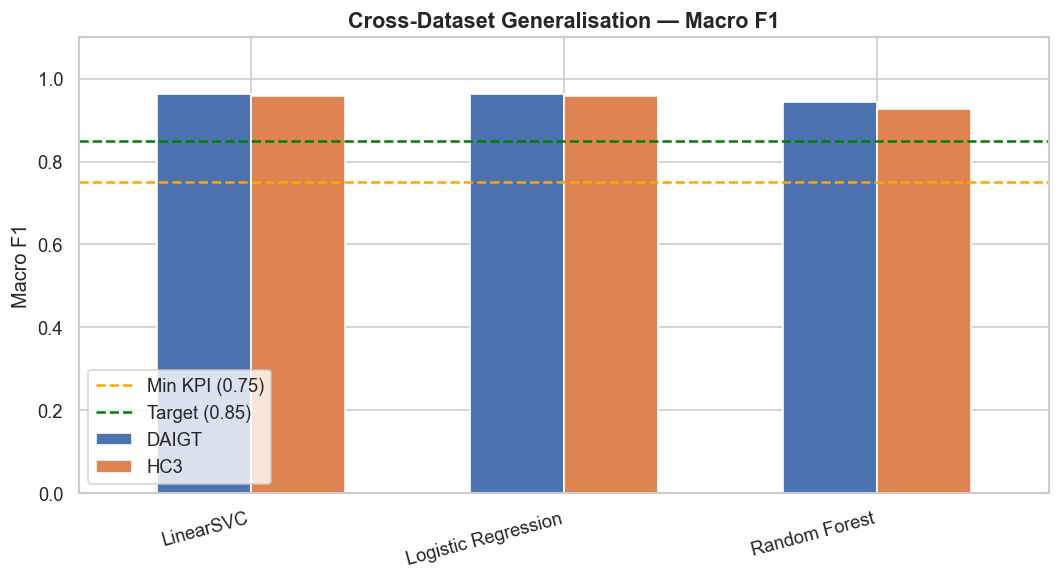

Saved: /Users/yashaswini11/Desktop/Team_project/project/fig_cross_dataset_f1.png


In [40]:
# ── Cross-dataset bar chart ───────────────────────────────────────────────────
if cross_df['Dataset'].nunique() >= 2:
    pivot = cross_df.pivot(index='Model', columns='Dataset', values='Macro F1')
    ax    = pivot.plot(kind='bar', figsize=(9, 5),
                       color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6)
    ax.axhline(KPI_MIN_CROSS,  color='orange', linestyle='--', lw=1.5,
               label=f'Min KPI ({KPI_MIN_CROSS})')
    ax.axhline(0.85, color='green', linestyle='--', lw=1.5, label='Target (0.85)')
    ax.set_title('Cross-Dataset Generalisation — Macro F1', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
    ax.legend()
    plt.tight_layout()
    fname = os.path.join(DATA_DIR, 'fig_cross_dataset_f1.png')
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")
else:
    print("  Only one dataset in test split — chart skipped.")
    print("  This is expected if only HC3 or only DAIGT was used.")

---
## 9. Save Best Classical Model

In [41]:
print("\n" + "=" * 60)
print("STEP 9: Saving best classical model")
print("=" * 60)

model_map = {
    'Logistic Regression': (best_lr,  lr_test_metrics),
    'Random Forest'      : (best_rf,  rf_test_metrics),
    'LinearSVC'          : (best_svm, svm_test_metrics),
}

best_name  = max(model_map, key=lambda k: model_map[k][1]['f1_macro'])
best_model = model_map[best_name][0]
best_f1    = model_map[best_name][1]['f1_macro']

joblib.dump(best_model, os.path.join(DATA_DIR, 'best_classical_model.pkl'))
# Overwrite tfidf_vectorizer.pkl to ensure it is always in sync
# with the best model (same features used during training)
joblib.dump(tfidf,      os.path.join(DATA_DIR, 'tfidf_vectorizer.pkl'))

print(f"  Best classical model : {best_name}")
print(f"  Test Macro F1        : {best_f1:.4f}")
print(f"  Saved: best_classical_model.pkl")
print(f"  Saved: tfidf_vectorizer.pkl  (confirmed in sync with best model)")


STEP 9: Saving best classical model
  Best classical model : Logistic Regression
  Test Macro F1        : 0.9645
  Saved: best_classical_model.pkl
  Saved: tfidf_vectorizer.pkl  (confirmed in sync with best model)


---
## 10. Final Summary

In [42]:
print("\n" + "=" * 60)
print("CLASSICAL ML — FINAL SUMMARY")
print("=" * 60)
print()
print(f"  Dummy baseline Macro F1 : {DUMMY_F1:.4f}")
print()
print(f"  {'Model':<25} {'Macro F1':>10} {'ROC-AUC':>10} {'Min KPI':>10} {'Target':>10}")
print("  " + "-" * 65)
for name, (_, metrics) in model_map.items():
    f1  = metrics['f1_macro']
    roc = metrics['roc_auc']
    mn  = '✓' if f1 >= KPI_MIN_F1    else '✗'
    tg  = '✓' if f1 >= KPI_TARGET_F1 else '—'
    print(f"  {name:<25} {f1:>10.4f} {roc:>10.4f} {mn:>10} {tg:>10}")
print()
print(f"  Best model : {best_name}  (Macro F1 = {best_f1:.4f})")
print()
print("  Artefacts saved:")
for fname in [
    'model_lr.pkl', 'model_rf.pkl', 'model_svm.pkl',
    'best_classical_model.pkl', 'tfidf_vectorizer.pkl',
    'classical_ml_results.csv', 'cross_dataset_results.csv',
    'fig_cm_logistic_regression.png', 'fig_cm_random_forest.png',
    'fig_cm_linearsvc.png',
    'fig_lr_features.png', 'fig_f1_comparison.png',
    'fig_roc_curves.png', 'fig_cross_dataset_f1.png'
]:
    print(f"    {fname}")
print()
print("  Next step:")
print("    -> 05_hybrid_cnn.ipynb  (loads glove artefacts from file 03)")
print()
print("=" * 60)


CLASSICAL ML — FINAL SUMMARY

  Dummy baseline Macro F1 : 0.3441

  Model                       Macro F1    ROC-AUC    Min KPI     Target
  -----------------------------------------------------------------
  Logistic Regression           0.9645     0.9943          ✓          ✓
  Random Forest                 0.9415     0.9873          ✓          ✓
  LinearSVC                     0.9637     0.9941          ✓          ✓

  Best model : Logistic Regression  (Macro F1 = 0.9645)

  Artefacts saved:
    model_lr.pkl
    model_rf.pkl
    model_svm.pkl
    best_classical_model.pkl
    tfidf_vectorizer.pkl
    classical_ml_results.csv
    cross_dataset_results.csv
    fig_cm_logistic_regression.png
    fig_cm_random_forest.png
    fig_cm_linearsvc.png
    fig_lr_features.png
    fig_f1_comparison.png
    fig_roc_curves.png
    fig_cross_dataset_f1.png

  Next step:
    -> 05_hybrid_cnn.ipynb  (loads glove artefacts from file 03)

